# 17 - Advanced Models

## Project Title: Traffic Accident Risk Prediction (TARP)

**Unit:** SIT782  
**Prepared by:** Khalid Ameen  

**Project Team:**  
- Suba (225094537)  
- Burhan (224802775)  
- Khalid (224696667)  

**Task:** Advanced Modelling for validated data set. (Week 7 of 8)

This notebook continues from `16_baseline_models.ipynb`. It trains advanced machine learning models for traffic accident severity prediction and compares their performance against the previous baseline models.

Advanced models included:
- Random Forest
- XGBoost

The main focus is not only overall accuracy, but also class-wise performance, especially for **Fatal accident**, because this is the most critical and most imbalanced severity class.

### Objective

This notebook extends the baseline modelling work by training and evaluating advanced machine learning models for traffic accident severity prediction in the TARP project.

The advanced modelling process focuses on:

- training advanced models such as Random Forest and XGBoost
- using the same selected modelling features from the baseline model notebook
- comparing advanced model performance against baseline results
- reviewing overall accuracy, macro F1-score, and weighted F1-score
- analysing class-wise performance for each severity category
- paying particular attention to **Fatal accident** prediction performance
- identifying the strongest final model for later reporting and dashboard use
- preparing model outputs that can support the final methodology and evaluation sections of the report

### Output

- `advanced_model_comparison.csv`
- `advanced_model_classwise_results.csv`
- `advanced_model_feature_importance.csv`
- trained Random Forest model results
- trained XGBoost model results
- comparison of baseline and advanced models
- class-wise performance summary for accident severity prediction
- final selected best model
- methodology notes for the report
- model evaluation notes for the report

## 1. Import Libraries

In [3]:
# -----------------------------
# 1. Import libraries
# -----------------------------
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier

import joblib

pd.set_option("display.max_columns", None)
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Validated Dataset

The validated modelling dataset was created in `14_data_validation.ipynb` and used again in `15_feature_visualisation.ipynb` and `16_baseline_models.ipynb`.

In [20]:
# -----------------------------
# 2. Load validated dataset
# -----------------------------
DATA_DIR = Path(r'D:\Git\SIT782\TARP01\MOP-Code\Playground\KhalidT12026\Traffic_Accident_Prediction\data\final')
validated_file = DATA_DIR / "validated_model_dataset.csv"

df = pd.read_csv(validated_file)

print("Dataset shape:", df.shape)
print("Number of columns:", len(df.columns))
df.head()

Dataset shape: (151947, 106)
Number of columns: 106


,ACCIDENT_NO,date,ACCIDENT_TIME,ACCIDENT_TYPE,DCA_CODE,DCA_CODE_DESCRIPTION,LIGHT_CONDITION,POLICE_ATTEND,ROAD_GEOMETRY,SEVERITY,SPEED_ZONE,RUN_OFFROAD,ROAD_NAME,ROAD_TYPE,ROAD_ROUTE_1,LGA_NAME,DTP_REGION,LATITUDE,LONGITUDE,VICGRID_X,VICGRID_Y,TOTAL_PERSONS,INJ_OR_FATAL,FATALITY,SERIOUSINJURY,OTHERINJURY,NONINJURED,MALES,FEMALES,BICYCLIST,PASSENGER,DRIVER,PEDESTRIAN,PILLION,MOTORCYCLIST,UNKNOWN,PED_CYCLIST_5_12,PED_CYCLIST_13_18,OLD_PED_65_AND_OVER,OLD_DRIVER_75_AND_OVER,YOUNG_DRIVER_18_25,NO_OF_VEHICLES,HEAVYVEHICLE,PASSENGERVEHICLE,MOTORCYCLE,PT_VEHICLE,DEG_URBAN_NAME,RMA,DIVIDED,STAT_DIV_NAME,hour,month_x,year_x,hour_of_day,day_of_week,weekend_flag,rush_hour,speed_zone_numeric,time_period,week_part,Min temperature (°C),Max temperature (°C),Total Rainfall (mm),Time of maximum gust,Direction of wind,max wind speed (km/h),max gust speed(km/h),max pressure (hPa),Max Humidity (%),Min Humidity (%),source_file,day,month_y,year_y,month_name,weekday,rain_indicator,temperature_range,humidity_range,gust_to_wind_ratio,is_hot_day,is_heavy_rain_day,wind_dir_Calm,wind_dir_E,wind_dir_ENE,wind_dir_ESE,wind_dir_N,wind_dir_N / NNW,wind_dir_NE,wind_dir_NNE,wind_dir_NNW,wind_dir_NW,wind_dir_NW/NNW,wind_dir_S,wind_dir_S / SSW,wind_dir_S/SSW,wind_dir_SE,wind_dir_SSE,wind_dir_SSW,wind_dir_SW,wind_dir_W,wind_dir_WNW,wind_dir_WSW,wind_dir_WSW / S,pedestrian_density,bicycle_density
0,T20230013207,2023-06-06,1900-01-01 22:14:00,Collision with vehicle,140,U TURN,Dark Street lights on,Yes,Not at intersection,Serious injury accident,50 km/hr,No,CUMBERLAND,ROAD,5749.0,MORELAND,INNER METRO,-37.723442,144.93985,2494697.067,2419717.845,2,2,0,1,1,0,2,0,0,0,2,0,0,0,0,0,0,0,0,0,2.0,0.0,2.0,0.0,0.0,MELB_URBAN,Arterial Other,Undivided,METRO,22.0,6,2023,22,Tuesday,0,0,50.0,Off-Peak,Weekday,13.5,17.3,0.0,14:00,N,24.0,44.0,1021.5,98.0,70.0,Weather archive 2015-2026,6.0,6.0,2023.0,June,Tuesday,0.0,3.8,28.0,1.833333,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.115603,0.026178
1,T20240014902,2024-04-19,1900-01-01 02:10:00,Collision with vehicle,140,U TURN,Dark Street lights on,Yes,Not at intersection,Other injury accident,40 km/hr,No,CHAPEL,STREET,9999.0,STONNINGTON,INNER METRO,-37.850610,144.99355,2499432.181,2405605.392,3,1,0,0,1,2,2,1,0,1,2,0,0,0,0,0,0,0,0,0,2.0,0.0,2.0,0.0,0.0,MELB_URBAN,Local Road,Undivided,METRO,2.0,4,2024,2,Friday,0,0,40.0,Off-Peak,Weekday,11.1,21.3,3.6,18:26,S,20.0,43.0,1014.2,100.0,39.0,Weather archive 2015-2026,19.0,4.0,2024.0,April,Friday,1.0,10.2,61.0,2.150000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.011888,0.000000
2,T20160009452,2016-04-30,1900-01-01 23:50:00,Collision with vehicle,120,HEAD ON (NOT OVERTAKING),Dark No street lights,Yes,Not at intersection,Serious injury accident,100 km/hr,No,BRANDY CREEK,ROAD,5532.0,BAW BAW,GIPPSLAND,-38.111640,145.92566,2581181.074,2376237.515,3,3,0,1,2,0,1,2,0,1,2,0,0,0,0,0,0,0,0,0,2.0,0.0,2.0,0.0,0.0,RURAL_VICTORIA,Arterial Other,Undivided,COUNTRY,23.0,4,2016,23,Saturday,1,0,100.0,Off-Peak,Weekend,20.3,23.8,0.0,14:50,N,28.0,46.0,1013.7,74.0,56.0,Weather archive 2015-2026,30.0,4.0,2016.0,April,Saturday,0.0,3.5,18.0,1.642857,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.269190,0.005236
3,T20230001223,2023-01-17,1900-01-01 15:56:00,Collision with vehicle,113,RIGHT NEAR (INTERSECTIONS ONLY),Day,Yes,Private property,Serious injury accident,100 km/hr,No,MIDLAND,HIGHWAY,2590.0,SHEPPARTON,HUME,-36.409386,145.25609,2522967.147,2565502.025,4,1,0,1,0,3,0,4,0,2,2,0,0,0,0,0,0,0,0,1,2.0,0.0,2.0,0.0,0.0,RURAL_VICTORIA,Arterial Highway,Undivided,COUNTRY,15.0,1,2023,15,Tuesday,0,1,100.0,Evening Peak,Weekday,20.0,37.1,4.0,12:30,N,28.0,39.0,1016.1,96.0,25.0,Weather archive 2015-2026,17.0,1.0,2023.0,January,Tuesday,1.0,17.1,71.0,1.392857,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.615111,0.089005
4,T2022000132

### Findings & Observations


The same validated dataset is used here to ensure the advanced models are trained and tested on data consistent with the baseline modelling stage.

## 3. Initial Modelling Checks

In [9]:
# -----------------------------
# 3. Initial modelling checks
# -----------------------------
target_col = "SEVERITY"

if target_col not in df.columns:
    raise KeyError(f"Target column '{target_col}' was not found in the dataset.")

print("Target distribution:")
print(df[target_col].value_counts())

print("\nTarget distribution (%):")
print((df[target_col].value_counts(normalize=True) * 100).round(2))

Target distribution:
SEVERITY
Other injury accident      94133
Serious injury accident    55277
Fatal accident              2537
Name: count, dtype: int64

Target distribution (%):
SEVERITY
Other injury accident      61.95
Serious injury accident    36.38
Fatal accident              1.67
Name: proportion, dtype: float64


### Findings & Observations

The target distribution confirms that the modelling dataset contains three severity classes: Other injury accident, Serious injury accident, and Fatal accident. The dataset is highly imbalanced, with Other injury accident representing the majority class and Fatal accident representing only 1.67% of the records.

This imbalance is important for model evaluation because overall accuracy alone may not reflect how well the model identifies rare but critical fatal accidents. Therefore, later evaluation will also consider class-wise precision, recall, F1-score, macro F1-score, and weighted F1-score.

## 4. Select Modelling Features

The same 11 features from the baseline notebook are reused so that model performance can be compared fairly.

In [10]:
# -----------------------------
# 4. Select modelling features
# -----------------------------
selected_features = [
    # Temporal features
    "hour_of_day",
    "weekend_flag",
    "rush_hour",

    # Road / traffic feature
    "speed_zone_numeric",

    # Mobility features
    "pedestrian_density",
    "bicycle_density",

    # Weather features
    "Total Rainfall (mm)",
    "Max temperature (°C)",
    "Min temperature (°C)",
    "Max Humidity (%)",
    "max wind speed (km/h)"
]

# Keep only columns available in the dataset
selected_features = [col for col in selected_features if col in df.columns]

model_df = df[selected_features + [target_col]].copy()

print("Selected features:", len(selected_features))
print(selected_features)
print("\nModel dataset shape:", model_df.shape)
model_df.head()

Selected features: 11
['hour_of_day', 'weekend_flag', 'rush_hour', 'speed_zone_numeric', 'pedestrian_density', 'bicycle_density', 'Total Rainfall (mm)', 'Max temperature (°C)', 'Min temperature (°C)', 'Max Humidity (%)', 'max wind speed (km/h)']

Model dataset shape: (151947, 12)


,hour_of_day,weekend_flag,rush_hour,speed_zone_numeric,pedestrian_density,bicycle_density,Total Rainfall (mm),Max temperature (°C),Min temperature (°C),Max Humidity (%),max wind speed (km/h),SEVERITY
0,22,0,0,50.0,0.115603,0.026178,0.0,17.3,13.5,98.0,24.0,Serious injury accident
1,2,0,0,40.0,0.011888,0.000000,3.6,21.3,11.1,100.0,20.0,Other injury accident
2,23,1,0,100.0,0.269190,0.005236,0.0,23.8,20.3,74.0,28.0,Serious injury accident
3,15,0,1,100.0,0.615111,0.089005,4.0,37.1,20.0,96.0,28.0,Serious injury accident
4,22,0,0,50.0,0.303805,0.123037,0.0,29.3,20.3,64.0,13.0,Serious injury accident


### Findings & Observations

The modelling dataset was prepared using the same 11 selected features that were used in the baseline modelling notebook. This ensures that the advanced models can be compared fairly against the previous Logistic Regression and Decision Tree results.

The selected features include temporal, road, mobility, and weather-related variables. The target variable is SEVERITY, which represents the accident severity category. The final modelling dataset contains 151,947 records and 12 columns, including 11 input features and 1 target column.

## 5. Prepare Features and Target

In [11]:
# -----------------------------
# 5. Prepare features and target
# -----------------------------
X = model_df[selected_features]
y = model_df[target_col]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Target classes:")
for idx, label in enumerate(label_encoder.classes_):
    print(idx, "=", label)

print("\nFeature shape:", X.shape)
print("Target shape:", y_encoded.shape)

Target classes:
0 = Fatal accident
1 = Other injury accident
2 = Serious injury accident

Feature shape: (151947, 11)
Target shape: (151947,)


### Findings & Observations

The target variable was encoded into numeric labels so that it can be used by the machine learning models. Fatal accident was encoded as 0, Other injury accident as 1, and Serious injury accident as 2.

The feature matrix contains 151,947 records with 11 selected input features, while the target array contains 151,947 severity labels. Since the feature and target row counts match, the dataset is ready for train-test splitting and model training.

## 6. Train-Test Split

The same stratified 80/20 split design used in the baseline notebook is applied again.

In [12]:
# -----------------------------
# 6. Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Training feature shape: (121557, 11)
Testing feature shape: (30390, 11)

Training class distribution:
0     2030
1    75306
2    44221
Name: count, dtype: int64

Testing class distribution:
0      507
1    18827
2    11056
Name: count, dtype: int64


### Findings & Observations

The dataset was split into training and testing sets so that the advanced models can be trained on one portion of the data and evaluated on unseen data. The training set contains 121,557 records, while the testing set contains 30,390 records.

The class distribution shows that all three severity categories are present in both the training and testing sets. This confirms that the stratified split preserved the original class balance, including the rare Fatal accident class. This is important because the model evaluation needs to measure performance across all severity classes, not only the majority classes.

## 7. Define Preprocessing

Tree-based models do not require feature scaling, so the preprocessing stage only handles missing numeric values using the median.

In [13]:
# -----------------------------
# 7. Define preprocessing
# -----------------------------
numeric_features = selected_features

numeric_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessor, numeric_features)
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


### Findings & Observations 

The preprocessing pipeline was defined to prepare the selected numeric features before model training. Since Random Forest and XGBoost are tree-based models, feature scaling is not required because these models split data based on feature thresholds rather than distance-based calculations.

The preprocessing step therefore focuses on handling missing numeric values. Median imputation was used because it is more robust to outliers than mean imputation. This ensures that any remaining missing values in the selected features are filled consistently before the models are trained.

## 8. Helper Function for Model Evaluation

In [14]:
# -----------------------------
# 8. Helper functions
# -----------------------------
def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (macro)": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1-score (macro)": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Precision (weighted)": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall (weighted)": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-score (weighted)": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


def classwise_report_df(model_name, y_true, y_pred, class_names):
    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
    rows = []
    for class_name in class_names:
        rows.append({
            "Model": model_name,
            "Class": class_name,
            "Precision": report[class_name]["precision"],
            "Recall": report[class_name]["recall"],
            "F1-score": report[class_name]["f1-score"],
            "Support": report[class_name]["support"]
        })
    return pd.DataFrame(rows)


def plot_confusion_matrix(cm, class_names, title):
    plt.figure(figsize=(7, 5))
    plt.imshow(cm)
    plt.colorbar(label="Count")
    plt.xticks(range(len(class_names)), class_names, rotation=45)
    plt.yticks(range(len(class_names)), class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()

print("Evaluation helper functions created.")

Evaluation helper functions created.


### Findings & Observations 

The evaluation helper functions were created to keep the model evaluation process consistent across all advanced models. These functions calculate key performance metrics such as accuracy, macro F1-score, weighted F1-score, classification reports, and confusion matrices.

Using the same evaluation functions for Random Forest and XGBoost ensures that both models are assessed in a fair and repeatable way. This is important because the dataset is imbalanced, so the evaluation must consider both overall performance and class-wise results, especially for the Fatal accident class.

## 9. Train Random Forest Model

Random Forest is an ensemble model that combines many decision trees. It is useful as an advanced model because it can capture non-linear relationships and reduce overfitting compared with a single decision tree.

In [15]:
# -----------------------------
# 9. Train Random Forest model
# -----------------------------
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            min_samples_leaf=30,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)
rf_preds = random_forest_model.predict(X_test)

print("Random Forest training completed.")

Random Forest training completed.


### Findings & Observations

The Random Forest model was trained as the first advanced model. Random Forest is an ensemble learning method that combines multiple decision trees to improve prediction stability and reduce overfitting compared with a single Decision Tree model.

In this model, class weighting was set to balanced to help address the strong imbalance in the SEVERITY target variable. This is important because Fatal accident cases represent only a small proportion of the dataset. The trained model was then used to generate predictions on the test set for later evaluation.

The model used 200 trees, a maximum tree depth of 12, and a minimum leaf size of 30. These settings were used to keep the model controlled and reduce the risk of overfitting while still allowing it to capture non-linear patterns in the data.

## 10. Evaluate Random Forest

Classification Report - Random Forest
                         precision    recall  f1-score   support

         Fatal accident       0.04      0.37      0.08       507
  Other injury accident       0.67      0.67      0.67     18827
Serious injury accident       0.41      0.27      0.32     11056

               accuracy                           0.52     30390
              macro avg       0.37      0.44      0.36     30390
           weighted avg       0.56      0.52      0.53     30390



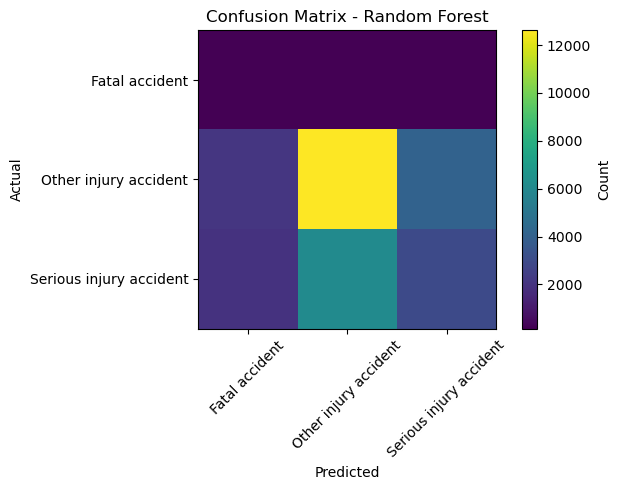

In [16]:
# -----------------------------
# 10. Evaluate Random Forest
# -----------------------------
print("Classification Report - Random Forest")
print(classification_report(
    y_test,
    rf_preds,
    target_names=label_encoder.classes_,
    zero_division=0
))

rf_cm = confusion_matrix(y_test, rf_preds)
plot_confusion_matrix(rf_cm, label_encoder.classes_, "Confusion Matrix - Random Forest")

### Findings & Observations

The Random Forest model achieved an overall accuracy of 0.52 and a weighted average F1-score of 0.53. This is an improvement over the baseline models in terms of overall accuracy and weighted F1-score.

The model performed best for the Other injury accident class, which is the majority class in the dataset. Its precision, recall, and F1-score were all 0.67 for this class.

For the Fatal accident class, the model achieved a recall of 0.37, meaning it was able to identify some fatal accident cases. However, the precision was only 0.04, which means many cases predicted as fatal were actually other severity classes. This reflects the difficulty of predicting rare fatal accidents in a highly imbalanced dataset.

The confusion matrix also shows that the model still confuses a large number of Serious injury accident cases with Other injury accident. Overall, Random Forest improves performance compared with the baseline models, but the rare fatal class remains difficult to predict accurately.

## 11. Train XGBoost Model

XGBoost is a gradient boosting model that builds trees sequentially, with each new tree attempting to improve the errors of previous trees. Sample weighting is used to reduce the impact of class imbalance.

In [17]:
# -----------------------------
# 11. Train XGBoost model
# -----------------------------
xgb_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

xgboost_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            objective="multi:softprob",
            num_class=len(label_encoder.classes_),
            eval_metric="mlogloss",
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            tree_method="hist",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Pass sample weights to the classifier step inside the pipeline
xgboost_model.fit(
    X_train,
    y_train,
    classifier__sample_weight=xgb_sample_weights
)

xgb_preds = xgboost_model.predict(X_test)

print("XGBoost training completed.")

XGBoost training completed.


### Findings & Observations

The XGBoost model was trained as the second advanced model. 

This model was included because it can capture complex non-linear relationships and often performs well on structured tabular datasets. After training, the model generated predictions on the test set, which will be evaluated in the next step using the same metrics as the Random Forest model.

## 12. Evaluate XGBoost

Classification Report - XGBoost
                         precision    recall  f1-score   support

         Fatal accident       0.04      0.50      0.07       507
  Other injury accident       0.67      0.64      0.65     18827
Serious injury accident       0.39      0.21      0.27     11056

               accuracy                           0.48     30390
              macro avg       0.37      0.45      0.33     30390
           weighted avg       0.56      0.48      0.51     30390



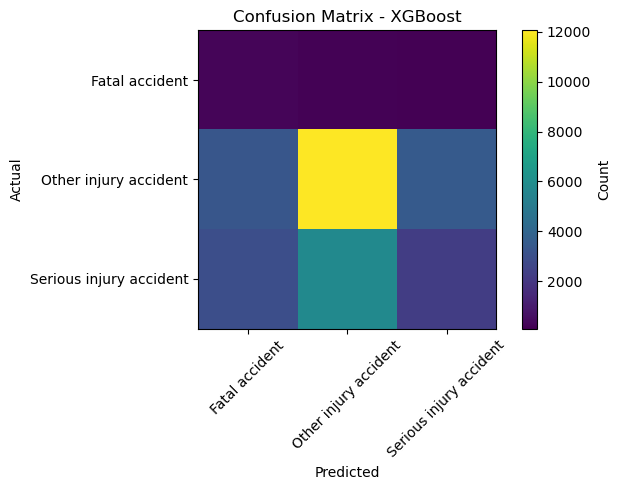

In [18]:
# -----------------------------
# 12. Evaluate XGBoost
# -----------------------------
print("Classification Report - XGBoost")
print(classification_report(
    y_test,
    xgb_preds,
    target_names=label_encoder.classes_,
    zero_division=0
))

xgb_cm = confusion_matrix(y_test, xgb_preds)
plot_confusion_matrix(xgb_cm, label_encoder.classes_, "Confusion Matrix - XGBoost")

### Findings & Observations

The XGBoost model achieved an overall accuracy of 0.48 and a weighted average F1-score of 0.51. Compared with Random Forest, XGBoost produced slightly lower overall performance, but it achieved a higher recall for the Fatal accident class.

For Fatal accident, XGBoost achieved a recall of 0.50, meaning it identified around half of the fatal accident cases in the test set. However, the precision was only 0.04, showing that many cases predicted as fatal were actually other severity classes. This indicates that XGBoost is more sensitive to the rare fatal class, but it also produces a high number of false positives.

The model performed best on the Other injury accident class, which remains the majority class in the dataset. The Serious injury accident class had weaker performance, with an F1-score of 0.27. Overall, XGBoost is useful for detecting more fatal accident cases, but Random Forest currently provides stronger balanced performance across the full dataset.

## 13. Compare Advanced Models

In [19]:
# -----------------------------
# 13. Compare advanced models
# -----------------------------
advanced_results = pd.DataFrame([
    evaluate_model("Random Forest", y_test, rf_preds),
    evaluate_model("XGBoost", y_test, xgb_preds)
])

advanced_results

,Model,Accuracy,Precision (macro),Recall (macro),F1-score (macro),Precision (weighted),Recall (weighted),F1-score (weighted)
0,Random Forest,0.518756,0.374305,0.437510,0.357419,0.564031,0.518756,0.533743
1,XGBoost,0.480520,0.366265,0.447649,0.332384,0.557587,0.480520,0.505370


### Findings & Observations

The advanced model comparison shows that Random Forest achieved stronger overall performance than XGBoost. Random Forest produced higher accuracy, macro F1-score, and weighted F1-score, indicating better general performance across the test dataset.

XGBoost achieved a slightly higher macro recall, which reflects its stronger ability to detect some minority-class cases, especially Fatal accident. However, its lower accuracy and lower F1-scores show that this came with more incorrect predictions overall.

Based on the comparison table, Random Forest is the preferred final model because it provides the best overall balance between accuracy, macro F1-score, and weighted F1-score. XGBoost remains useful from a road safety perspective because it identified more fatal accident cases, but it also produced more false positives.

## 14. Load Baseline Results and Compare All Models

If the baseline comparison file exists, it will be loaded. If not, the known baseline results from the previous notebook are used as a fallback.

In [34]:
# -----------------------------
# 14. Compare baseline and advanced models
# -----------------------------
OUTPUT_DIR = Path(r'D:\Git\SIT782\TARP01\MOP-Code\Playground\KhalidT12026\Traffic_Accident_Prediction\outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

baseline_file = OUTPUT_DIR / "baseline_model_comparison.csv"

if baseline_file.exists():
    baseline_results = pd.read_csv(baseline_file)
    print("Loaded baseline results from:", baseline_file)
else:
    print("Baseline result file not found. Using known baseline results from Week 6 notebook.")
    baseline_results = pd.DataFrame([
        {
            "Model": "Logistic Regression",
            "Accuracy": 0.451,
            "Precision (macro)": np.nan,
            "Recall (macro)": np.nan,
            "F1-score (macro)": 0.314,
            "Precision (weighted)": np.nan,
            "Recall (weighted)": np.nan,
            "F1-score (weighted)": 0.484,
        },
        {
            "Model": "Decision Tree",
            "Accuracy": 0.460,
            "Precision (macro)": np.nan,
            "Recall (macro)": np.nan,
            "F1-score (macro)": 0.323,
            "Precision (weighted)": np.nan,
            "Recall (weighted)": np.nan,
            "F1-score (weighted)": 0.493,
        }
    ])

all_model_results = pd.concat([baseline_results, advanced_results], ignore_index=True)
all_model_results

Loaded baseline results from: D:\Git\SIT782\TARP01\MOP-Code\Playground\KhalidT12026\Traffic_Accident_Prediction\outputs\baseline_model_comparison.csv


,Model,Accuracy,Precision (macro),Recall (macro),F1-score (macro),Precision (weighted),Recall (weighted),F1-score (weighted)
0,Logistic Regression,0.451102,0.364228,0.449774,0.314139,0.557436,0.451102,0.484276
1,Decision Tree,0.459526,0.364736,0.442278,0.323380,0.556985,0.459526,0.493191
2,Random Forest,0.518756,0.374305,0.437510,0.357419,0.564031,0.518756,0.533743
3,XGBoost,0.480520,0.366265,0.447649,0.332384,0.557587,0.480520,0.505370


### Findings & Observations

The combined model comparison shows that the advanced models improved performance compared with the baseline models. Logistic Regression and Decision Tree provided useful benchmark results, but both were outperformed by Random Forest and XGBoost.

Random Forest achieved the strongest overall performance, with the highest accuracy, macro F1-score, and weighted F1-score among all tested models. This indicates that Random Forest was better able to capture non-linear relationships in the selected road, temporal, mobility, and weather-related features.

XGBoost also improved over the baseline models, particularly when compared with Logistic Regression and Decision Tree in terms of weighted F1-score. However, Random Forest remained the best overall model based on the comparison table.

Based on these results, Random Forest is selected as the preferred final model for this stage of the TARP project.

## 15. Visualise Model Comparison

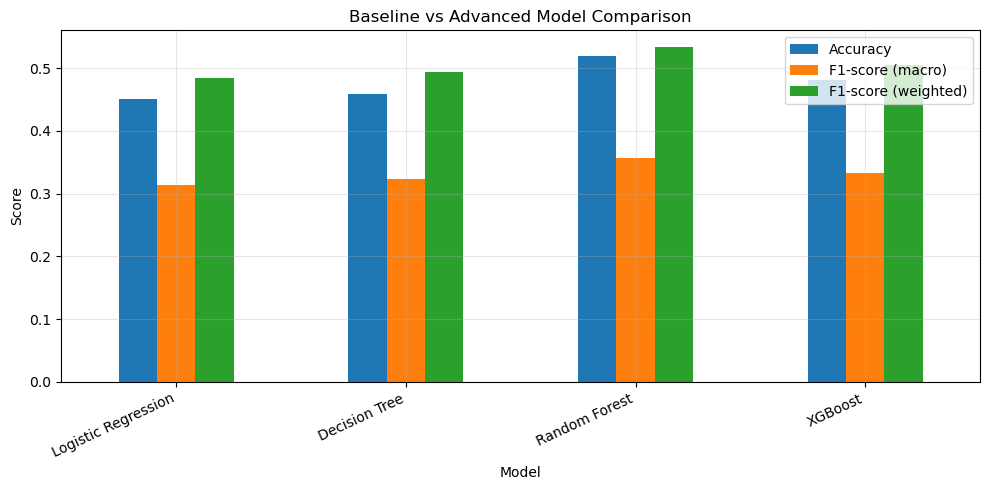

In [24]:
# -----------------------------
# 15. Visualise model comparison
# -----------------------------
metrics_to_plot = ["Accuracy", "F1-score (macro)", "F1-score (weighted)"]

comparison_plot_df = all_model_results.set_index("Model")[metrics_to_plot]

comparison_plot_df.plot(kind="bar", figsize=(10, 5))
plt.ylabel("Score")
plt.title("Baseline vs Advanced Model Comparison")
plt.xticks(rotation=25, ha="right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Findings & Observations

The comparison chart provides a visual summary of baseline and advanced model performance. It compares Accuracy, Macro F1-score, and Weighted F1-score across Logistic Regression, Decision Tree, Random Forest, and XGBoost.

The chart shows that Random Forest achieved the strongest overall performance across the selected evaluation metrics. It outperformed both baseline models and XGBoost in terms of accuracy, macro F1-score, and weighted F1-score.

This visual comparison supports the earlier table-based findings and provides clear evidence for selecting Random Forest as the preferred final model for this stage of the project.

## 16. Class-wise Performance Review

This section focuses on how each advanced model performs for each severity class, especially **Fatal accident**.

In [25]:
# -----------------------------
# 16. Class-wise performance review
# -----------------------------
classwise_results = pd.concat([
    classwise_report_df("Random Forest", y_test, rf_preds, label_encoder.classes_),
    classwise_report_df("XGBoost", y_test, xgb_preds, label_encoder.classes_)
], ignore_index=True)

classwise_results

,Model,Class,Precision,Recall,F1-score,Support
0,Random Forest,Fatal accident,0.044186,0.374753,0.079051,507.0
1,Random Forest,Other injury accident,0.668132,0.670048,0.669089,18827.0
2,Random Forest,Serious injury accident,0.410598,0.267728,0.324117,11056.0
3,XGBoost,Fatal accident,0.038544,0.495069,0.071520,507.0
4,XGBoost,Other injury accident,0.669591,0.640569,0.654759,18827.0
5,XGBoost,Serious injury accident,0.390660,0.207308,0.270874,11056.0


In [26]:
# Focus specifically on fatal accident performance
fatal_class_name = "Fatal accident"

fatal_performance = classwise_results[classwise_results["Class"] == fatal_class_name].copy()
fatal_performance

,Model,Class,Precision,Recall,F1-score,Support
0,Random Forest,Fatal accident,0.044186,0.374753,0.079051,507.0
3,XGBoost,Fatal accident,0.038544,0.495069,0.071520,507.0


### Findings & Observations

The class-wise performance comparison shows that both advanced models struggled with the Fatal accident class due to strong class imbalance. Fatal accident had only 507 records in the test set, making it much harder for the models to learn and predict accurately.

XGBoost achieved higher recall for Fatal accident, meaning it identified more actual fatal accident cases than Random Forest. However, Random Forest achieved slightly better precision and F1-score for the Fatal accident class.

This means XGBoost may be more useful when the priority is detecting as many fatal accident cases as possible, while Random Forest provides a slightly better balance between precision and recall. Since Random Forest also achieved stronger overall model performance, it remains the preferred final model at this stage.

## 17. Feature Importance

In [27]:
# -----------------------------
# 17. Random Forest feature importance
# -----------------------------
rf_classifier = random_forest_model.named_steps["classifier"]

rf_feature_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": rf_classifier.feature_importances_
}).sort_values("Importance", ascending=False)

rf_feature_importance

,Feature,Importance
3,speed_zone_numeric,0.316591
8,Min temperature (°C),0.108772
7,Max temperature (°C),0.106140
4,pedestrian_density,0.093509
9,Max Humidity (%),0.090413
5,bicycle_density,0.080423
10,max wind speed (km/h),0.068850
0,hour_of_day,0.065471
6,Total Rainfall (mm),0.047663
2,rush_hour,0.011826


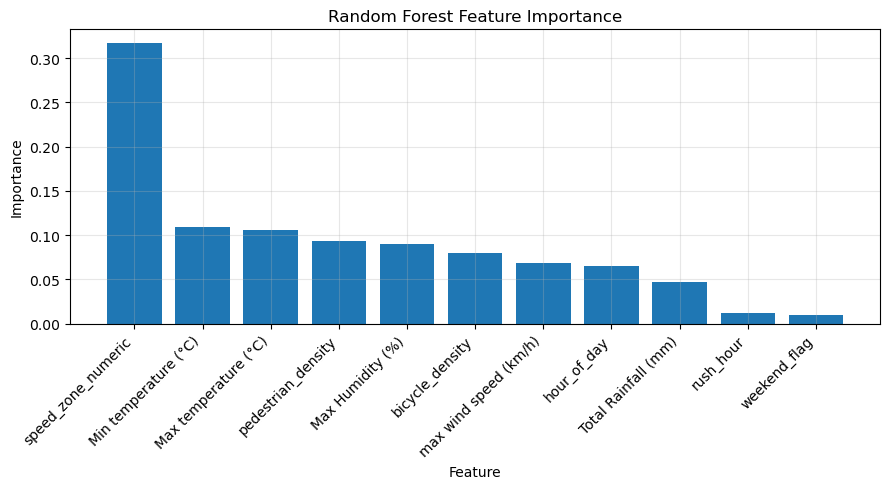

In [28]:
plt.figure(figsize=(9, 5))
plt.bar(rf_feature_importance["Feature"], rf_feature_importance["Importance"])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=45, ha="right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
# -----------------------------
# 18. XGBoost feature importance
# -----------------------------
xgb_classifier = xgboost_model.named_steps["classifier"]

xgb_feature_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": xgb_classifier.feature_importances_
}).sort_values("Importance", ascending=False)

xgb_feature_importance

,Feature,Importance
3,speed_zone_numeric,0.419487
2,rush_hour,0.093633
0,hour_of_day,0.070747
4,pedestrian_density,0.063388
5,bicycle_density,0.060313
7,Max temperature (°C),0.052221
9,Max Humidity (%),0.050202
8,Min temperature (°C),0.049402
10,max wind speed (km/h),0.048399
6,Total Rainfall (mm),0.047564


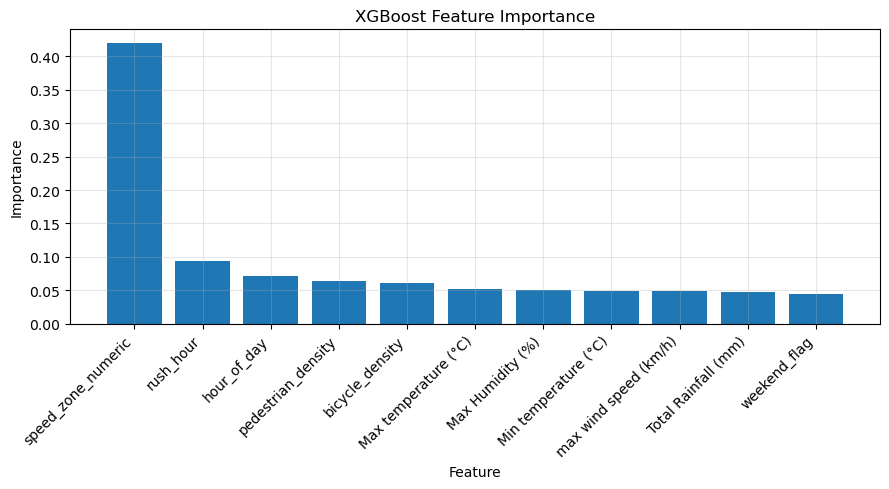

In [30]:
plt.figure(figsize=(9, 5))
plt.bar(xgb_feature_importance["Feature"], xgb_feature_importance["Importance"])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("XGBoost Feature Importance")
plt.xticks(rotation=45, ha="right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Findings & Observations

The feature importance results show that speed_zone_numeric was the most influential feature for both Random Forest and XGBoost. This suggests that road speed environment plays a major role in predicting accident severity.

For Random Forest, the next most important features included temperature, pedestrian density, humidity, bicycle density, wind speed, and hour of day. This indicates that the model used a combination of road, weather, mobility, and temporal features when predicting severity.

For XGBoost, speed_zone_numeric had an even stronger influence compared with the other features. The next most important features were rush_hour, hour_of_day, pedestrian_density, and bicycle_density. This suggests that XGBoost relied heavily on road speed conditions, along with time-based and mobility-related patterns.

Although speed_zone_numeric was the strongest feature in both models, the remaining importance scores show that severity prediction also depends on environmental, temporal, and mobility-related variables. This supports the use of machine learning models that can combine multiple factors rather than relying on a single feature.

Overall, the feature importance results support the project finding that accident severity is not explained by one factor alone. However, speed zone appears to be the strongest individual predictor among the selected modelling features.

## 18. Select Best Final Model

The best model is selected using macro F1-score as the primary metric because it treats all classes more equally than accuracy. Fatal accident recall is also reviewed as an important secondary consideration.

In [31]:
# -----------------------------
# 19. Select best final model
# -----------------------------
advanced_ranked = advanced_results.sort_values(
    by=["F1-score (macro)", "F1-score (weighted)", "Accuracy"],
    ascending=False
).reset_index(drop=True)

best_model_name = advanced_ranked.loc[0, "Model"]

if best_model_name == "Random Forest":
    best_model = random_forest_model
    best_preds = rf_preds
elif best_model_name == "XGBoost":
    best_model = xgboost_model
    best_preds = xgb_preds
else:
    raise ValueError("Best model name not recognised.")

print("Selected best final model:", best_model_name)
advanced_ranked

Selected best final model: Random Forest


,Model,Accuracy,Precision (macro),Recall (macro),F1-score (macro),Precision (weighted),Recall (weighted),F1-score (weighted)
0,Random Forest,0.518756,0.374305,0.437510,0.357419,0.564031,0.518756,0.533743
1,XGBoost,0.480520,0.366265,0.447649,0.332384,0.557587,0.480520,0.505370


In [32]:
# Best model class-wise report
best_classwise = classwise_report_df(
    best_model_name,
    y_test,
    best_preds,
    label_encoder.classes_
)

best_classwise

,Model,Class,Precision,Recall,F1-score,Support
0,Random Forest,Fatal accident,0.044186,0.374753,0.079051,507.0
1,Random Forest,Other injury accident,0.668132,0.670048,0.669089,18827.0
2,Random Forest,Serious injury accident,0.410598,0.267728,0.324117,11056.0


### Final Model Selection Note

Random Forest was selected as the best final model because it achieved the strongest overall performance among the advanced models. It produced higher accuracy, macro F1-score, and weighted F1-score than XGBoost.

The selected model performed best on the Other injury accident class, which is also the majority class in the dataset. Performance on Serious injury accident was moderate, while Fatal accident remained the most difficult class to predict due to its very low representation in the dataset.

Although XGBoost achieved higher recall for Fatal accident, Random Forest provided a better overall balance across the full model evaluation metrics. Therefore, Random Forest was selected as the preferred final model for this stage of the TARP project.

The final model selection confirms that Random Forest is the most suitable model for the current dataset and feature set, while further improvement is still needed for rare fatal accident prediction.

## 19. Save Advanced Model Outputs

In [35]:
# -----------------------------
# 20. Save outputs
# -----------------------------
OUTPUT_DIR = Path(r'D:\Git\SIT782\TARP01\MOP-Code\Playground\KhalidT12026\Traffic_Accident_Prediction\outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

advanced_results_file = OUTPUT_DIR / "advanced_model_comparison.csv"
all_results_file = OUTPUT_DIR / "all_model_comparison.csv"
classwise_file = OUTPUT_DIR / "advanced_classwise_performance.csv"
rf_importance_file = OUTPUT_DIR / "random_forest_feature_importance.csv"
xgb_importance_file = OUTPUT_DIR / "xgboost_feature_importance.csv"
best_model_file = OUTPUT_DIR / "best_final_model.pkl"
label_encoder_file = OUTPUT_DIR / "severity_label_encoder.pkl"

advanced_results.to_csv(advanced_results_file, index=False)
all_model_results.to_csv(all_results_file, index=False)
classwise_results.to_csv(classwise_file, index=False)
rf_feature_importance.to_csv(rf_importance_file, index=False)
xgb_feature_importance.to_csv(xgb_importance_file, index=False)

joblib.dump(best_model, best_model_file)
joblib.dump(label_encoder, label_encoder_file)

print("Saved files:")
print("-", advanced_results_file)
print("-", all_results_file)
print("-", classwise_file)
print("-", rf_importance_file)
print("-", xgb_importance_file)
print("-", best_model_file)
print("-", label_encoder_file)

Saved files:
- D:\Git\SIT782\TARP01\MOP-Code\Playground\KhalidT12026\Traffic_Accident_Prediction\outputs\advanced_model_comparison.csv
- D:\Git\SIT782\TARP01\MOP-Code\Playground\KhalidT12026\Traffic_Accident_Prediction\outputs\all_model_comparison.csv
- D:\Git\SIT782\TARP01\MOP-Code\Playground\KhalidT12026\Traffic_Accident_Prediction\outputs\advanced_classwise_performance.csv
- D:\Git\SIT782\TARP01\MOP-Code\Playground\KhalidT12026\Traffic_Accident_Prediction\outputs\random_forest_feature_importance.csv
- D:\Git\SIT782\TARP01\MOP-Code\Playground\KhalidT12026\Traffic_Accident_Prediction\outputs\xgboost_feature_importance.csv
- D:\Git\SIT782\TARP01\MOP-Code\Playground\KhalidT12026\Traffic_Accident_Prediction\outputs\best_final_model.pkl
- D:\Git\SIT782\TARP01\MOP-Code\Playground\KhalidT12026\Traffic_Accident_Prediction\outputs\severity_label_encoder.pkl


### Findings and Observations 

The final outputs from the advanced modelling notebook were saved successfully. These files include the advanced model comparison, combined baseline and advanced model comparison, class-wise performance results, feature importance outputs, the selected final model, and the severity label encoder.

Saving these outputs supports reproducibility and allows the results to be reused in later stages of the project, including reporting, dashboard development, and possible deployment. The saved final model file can also be used later without retraining the model from the beginning.

## 20. A note on Methodology

The modelling stage used the validated integrated dataset prepared during the previous project phase. After validation, the target variable contained three severity classes: Fatal accident, Serious injury accident, and Other injury accident. Because the dataset was highly imbalanced, the modelling process used a stratified train-test split to preserve the class distribution across both training and testing sets.

The same set of modelling features used in the baseline notebook was retained for advanced modelling. These features covered temporal factors, road or traffic conditions, mobility density, and weather conditions. Reusing the same predictors ensured that the advanced models could be compared fairly against the baseline Logistic Regression and Decision Tree models.

Two advanced models were trained: Random Forest and XGBoost. Random Forest was selected because it combines multiple decision trees and can capture non-linear relationships while reducing the risk of overfitting compared with a single tree. XGBoost was selected because it is a strong gradient boosting method that builds trees sequentially and often performs well on structured tabular datasets.

Class imbalance was addressed through balanced class weighting in Random Forest and sample weighting in XGBoost. This was important because Fatal accident cases represented only a small proportion of the dataset. Without this adjustment, the models could have focused too heavily on the majority classes and performed poorly on the rare fatal accident class.

Model performance was evaluated using accuracy, macro precision, macro recall, macro F1-score, weighted precision, weighted recall, and weighted F1-score. Macro F1-score was treated as an important metric because it gives more balanced attention to minority and majority classes. Class-wise precision, recall, and F1-score were also reviewed, with particular attention given to Fatal accident prediction because this class is the most safety-critical and under-represented in the dataset.

After evaluation, Random Forest was selected as the best final model because it achieved the strongest overall performance across accuracy, macro F1-score, and weighted F1-score. XGBoost achieved higher recall for Fatal accident, meaning it detected more fatal cases, but it also produced more false positives and had weaker overall performance. Therefore, Random Forest was chosen as the preferred final model for this stage of the TARP project.

## 21. A note on Model Evaluation

The advanced models were compared against the baseline Logistic Regression and Decision Tree results from the previous notebook. Accuracy was reviewed, but it was not used as the only decision metric because the severity classes were highly imbalanced. In this context, a model could achieve reasonable accuracy by performing well on the majority class while still performing poorly on the rare Fatal accident class.

The comparison showed that Random Forest achieved the strongest overall performance. It recorded an accuracy of 0.519, macro F1-score of 0.357, and weighted F1-score of 0.534. This was higher than both baseline models and also higher than XGBoost across the main overall evaluation metrics. XGBoost achieved an accuracy of 0.481, macro F1-score of 0.332, and weighted F1-score of 0.505.

Class-wise performance was also reviewed because the dataset was imbalanced. The Random Forest model performed best on the Other injury accident class, which was the majority class. Its performance on Serious injury accident was moderate, while Fatal accident remained the most difficult class to predict because it had very limited representation in the dataset.

For the Fatal accident class, Random Forest achieved a recall of 0.375 and an F1-score of 0.079. XGBoost achieved a higher fatal accident recall of 0.495, meaning it identified more actual fatal accident cases. However, XGBoost had slightly lower fatal accident precision and weaker overall model performance compared with Random Forest. This means XGBoost was more sensitive to fatal accident detection, but it also produced more false positives.

The final model was selected based primarily on macro F1-score, weighted F1-score, overall accuracy, and class-wise performance. Random Forest was selected as the best final model because it provided the strongest overall balance across the evaluation metrics. Although XGBoost showed better recall for Fatal accident, Random Forest was more reliable across the full dataset and is therefore the preferred final model for this stage of the TARP project.

The selected model and evaluation outputs were saved for later use in the final report, dashboard development, and possible deployment or demonstration activities.

## Final Summary

This notebook completed the Week 7 advanced modelling task. The work extended the previous baseline modelling stage by training advanced machine learning models and comparing their performance against earlier baseline results.

Completed work:

- Trained two advanced models: Random Forest and XGBoost
- Compared advanced models with baseline Logistic Regression and Decision Tree results
- Reviewed overall model performance using accuracy, macro F1-score, and weighted F1-score
- Analysed class-wise performance for all severity classes
- Focused specifically on Fatal accident prediction because it is the rarest and most safety-critical class
- Identified that XGBoost achieved higher Fatal accident recall, but Random Forest performed better overall
- Selected Random Forest as the best final model based on balanced evaluation metrics
- Reviewed feature importance and identified speed_zone_numeric as the strongest predictor in both advanced models
- Saved model comparison tables, class-wise results, feature importance files, the selected final model, and the label encoder
- Drafted methodology and model evaluation sections for the final report

Overall, the Week 7 modelling work showed that advanced models improved performance compared with the baseline models. Random Forest was selected as the preferred final model for this stage of the TARP project, although further improvement is still needed for predicting rare Fatal accident cases.